# ISyE 6525 — HW2 Question 3: Convolution and denoising

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

IMAGE_PATH = Path("Flower.jpg")
RNG = np.random.default_rng(6525)

def mse(reference, estimate):
    reference = np.asarray(reference, dtype=float)
    estimate = np.asarray(estimate, dtype=float)
    return float(np.mean((reference - estimate) ** 2))

def psnr(reference, estimate):
    error = mse(reference, estimate)
    return float("inf") if error == 0 else float(10 * np.log10(255.0 ** 2 / error))

def show_pair(first, second, first_label, second_label):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for ax, image, title in zip(axes, (first, second), (first_label, second_label)):
        ax.imshow(image, cmap="gray", vmin=0, vmax=255)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Load the image

Open the source image without applying any transformations.

Clean grayscale image dimensions: (512, 768)


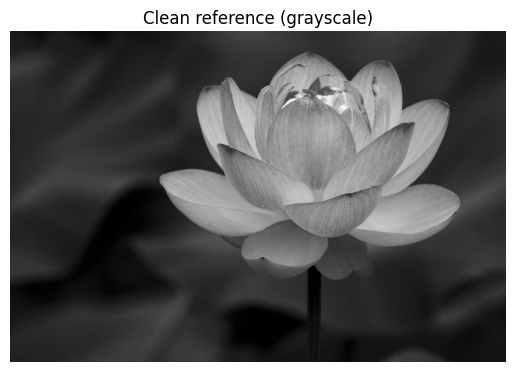

In [2]:
with Image.open(IMAGE_PATH) as source:
    clean = np.asarray(source.convert("L"), dtype=np.float64)
print("Clean grayscale image dimensions:", clean.shape)
plt.imshow(clean, cmap="gray", vmin=0, vmax=255)
plt.title("Clean reference (grayscale)")
plt.axis("off")
plt.show()

## (a) Manual linear filtering (10 pts)

Use explicit pixel/kernel/channel loops, odd-sized kernels and zero-padding. Double flip the kernel before accumulating.

In [3]:
def my_imfilter(image, kernel):
    """Manual zero-padded convolution, for 2-D grayscale or 3-D color images."""
    image = np.asarray(image)
    kernel = np.asarray(kernel, dtype=np.float64)
    if image.ndim not in (2, 3) or not np.issubdtype(image.dtype, np.number):
        raise ValueError("image must be a numeric 2-D or 3-D array")
    if kernel.ndim != 2 or any(s == 0 or s % 2 == 0 for s in kernel.shape):
        raise ValueError("kernel height and width must be positive odd numbers")
    grayscale = image.ndim == 2
    values = image.astype(np.float64)
    if grayscale:
        values = values[:, :, None]
    height, width, channels = values.shape
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(values, ((ph, ph), (pw, pw), (0, 0)), mode="constant")
    # Flip the kernel horizontally and vertically for convolution
    weights = kernel[::-1, ::-1]
    result = np.empty((height, width, channels), dtype=np.float64)
    for row in range(height):
        for col in range(width):
            for channel in range(channels):
                total = 0.0
                for kr in range(kh):
                    for kc in range(kw):
                        total += padded[row + kr, col + kc, channel] * weights[kr, kc]
                result[row, col, channel] = total
    return result[:, :, 0] if grayscale else result

# Verify identity, asymmetric kernel orientation, zero-padding, color channels, and validation.
sample = np.array([[1., 2., 3.], [4., 5., 6.]])
np.testing.assert_allclose(my_imfilter(sample, [[1]]), sample)
np.testing.assert_allclose(my_imfilter(sample, [[1, 0, 0]]),
                           [[2., 3., 0.], [5., 6., 0.]])
np.testing.assert_allclose(my_imfilter(sample, np.ones((3, 3)))[0, 0], 12.)
rgb = np.stack([sample, sample * 2, sample * 3], axis=-1)
np.testing.assert_allclose(my_imfilter(rgb, [[1]])[:, :, 2], sample * 3)
for bad_kernel in (np.ones((2, 3)), np.ones((3, 2)), np.ones((0, 3))):
    try:
        my_imfilter(sample, bad_kernel)
    except ValueError:
        pass
    else:
        raise AssertionError("Even-sized or empty kernels must raise ValueError")
print("Manual filtering sanity tests passed.")

Manual filtering sanity tests passed.


## (b) Noisy images and their PSNR (6 pts)

J1: Gaussian noise with mean 0 and variance 0.01 on [0,1], equivalent to standard deviation 25.5 on the 0–255 scale. 

J2: Salt-and-pepper noise sample approximately 5% of the pixels (half to 0 and half to 255).

393216
(512, 768)


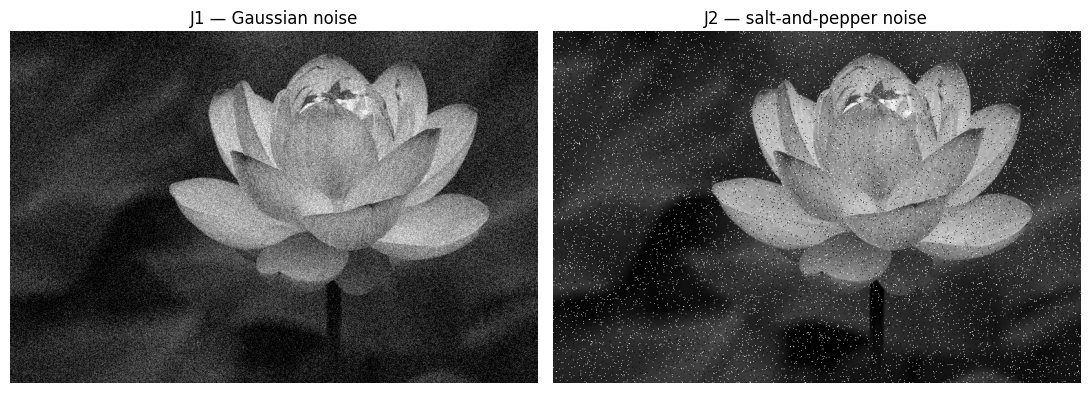

J1 PSNR: 20.490 dB
J2 PSNR: 17.603 dB
Selected 19661/393216 (5.00%) positions; 9830 salt and 9831 pepper.


In [4]:
J1 = np.clip(clean + RNG.normal(0, np.sqrt(0.01) * 255, size=clean.shape), 0, 255)
J2 = clean.copy()
print(clean.size)
print(clean.shape)
n_corrupt = round(0.05 * clean.size)
indices = RNG.choice(clean.size, size=n_corrupt, replace=False)
n_salt = n_corrupt // 2
J2.ravel()[indices[:n_salt]] = 255
J2.ravel()[indices[n_salt:]] = 0
show_pair(J1, J2, "J1 — Gaussian noise", "J2 — salt-and-pepper noise")
print(f"J1 PSNR: {psnr(clean, J1):.3f} dB")
print(f"J2 PSNR: {psnr(clean, J2):.3f} dB")
print(f"Selected {n_corrupt}/{clean.size} ({n_corrupt / clean.size:.2%}) positions; {n_salt} salt and {n_corrupt - n_salt} pepper.")

## (c) Five 3×3 filters applied to both noisy images (10 pts)


### (c.1) Arithmetic mean filter

Use the $3\times3$ kernel $h=\frac{1}{9}\mathbf{1}_{3\times3}$.

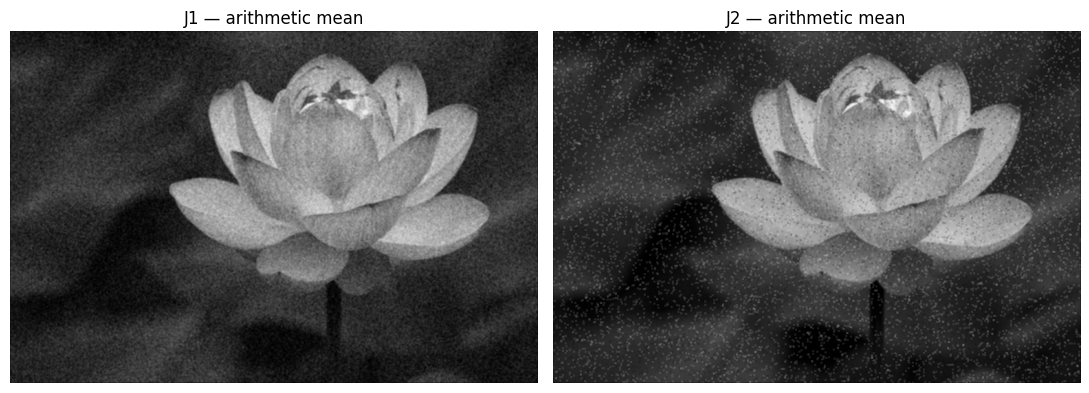

In [5]:
filtered = {"J1": {}, "J2": {}}
mean_kernel = np.ones((3, 3), dtype=float) / 9
for name, noisy in (("J1", J1), ("J2", J2)):
    filtered[name]["Arithmetic mean"] = np.clip(my_imfilter(noisy, mean_kernel), 0, 255)
show_pair(filtered["J1"]["Arithmetic mean"], filtered["J2"]["Arithmetic mean"], "J1 — arithmetic mean", "J2 — arithmetic mean")

### (c.2) Gaussian filter

Construct and report a normalized $3\times3$ kernel with $\sigma=1$:

$$
h_g(x,y)\propto\exp\left(-\frac{x^2+y^2}{2\sigma^2}\right).
$$

Normalized 3×3 Gaussian kernel, sigma=1:
[[0.075114 0.123841 0.075114]
 [0.123841 0.20418  0.123841]
 [0.075114 0.123841 0.075114]]


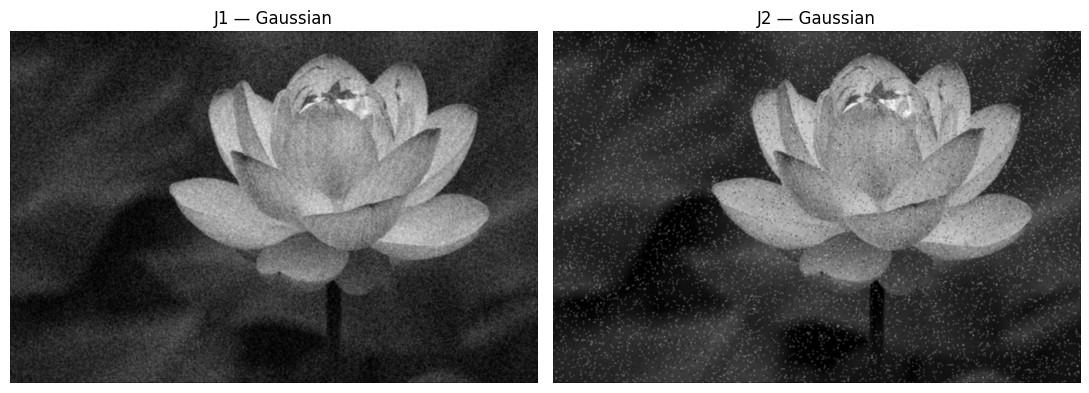

In [6]:
yy, xx = np.mgrid[-1:2, -1:2]
gaussian_kernel = np.exp(-(xx ** 2 + yy ** 2) / (2 * 1.0 ** 2))
gaussian_kernel /= gaussian_kernel.sum()
print("Normalized 3×3 Gaussian kernel, sigma=1:")
print(np.array2string(gaussian_kernel, precision=6, suppress_small=True))
np.testing.assert_allclose(gaussian_kernel.sum(), 1)
for name, noisy in (("J1", J1), ("J2", J2)):
    filtered[name]["Gaussian"] = np.clip(my_imfilter(noisy, gaussian_kernel), 0, 255)
show_pair(filtered["J1"]["Gaussian"], filtered["J2"]["Gaussian"], "J1 — Gaussian", "J2 — Gaussian")

#### Utility for (c.3), (c.4), (c.5)
Sort the intensities of the 3×3 neighborhood for median, minimum, and maximum filters.

In [7]:
def rank_filter(image, mode):
    # only 3x3 filters and 2-D grayscale images are supported
    if mode not in ("median", "minimum", "maximum"):
        raise ValueError("Unknown mode")
    arr = np.asarray(image, dtype=np.float64)
    if arr.ndim != 2:
        raise ValueError("Expected a 2-D grayscale image")
    padded = np.pad(arr, ((1, 1), (1, 1)), mode="constant")
    result = np.empty_like(arr)
    H, W = arr.shape
    for row in range(H):
        for col in range(W):
            neighborhood = padded[row:row+3, col:col+3].ravel()
            if mode == "median":
                result[row, col] = sorted(neighborhood)[4]
            elif mode == "minimum":
                result[row, col] = min(neighborhood)
            else:
                result[row, col] = max(neighborhood)
    return result


### (c.3) Median filter

Replace each pixel with the median intensity in its $3\times3$ neighbourhood.

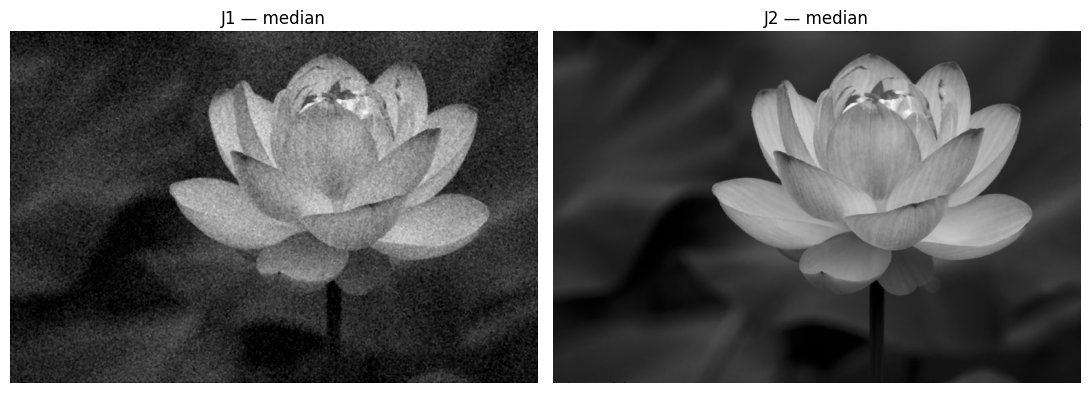

In [8]:
for name, noisy in (("J1", J1), ("J2", J2)):
    filtered[name]["Median"] = rank_filter(noisy, "median")
show_pair(filtered["J1"]["Median"], filtered["J2"]["Median"], "J1 — median", "J2 — median")

### (c.4) Minimum filter

Use $\hat f(x,y)=\min_{(r,c)\in S_{xy}}g(r,c)$ over each $3\times3$ neighbourhood.

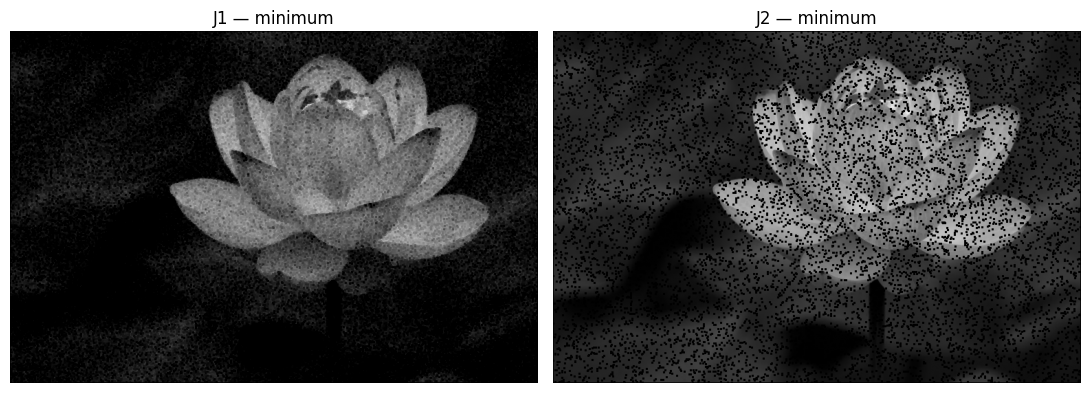

In [9]:
for name, noisy in (("J1", J1), ("J2", J2)):
    filtered[name]["Minimum"] = rank_filter(noisy, "minimum")
show_pair(filtered["J1"]["Minimum"], filtered["J2"]["Minimum"], "J1 — minimum", "J2 — minimum")

### (c.5) Maximum filter

Use $\hat f(x,y)=\max_{(r,c)\in S_{xy}}g(r,c)$ over each $3\times3$ neighbourhood.

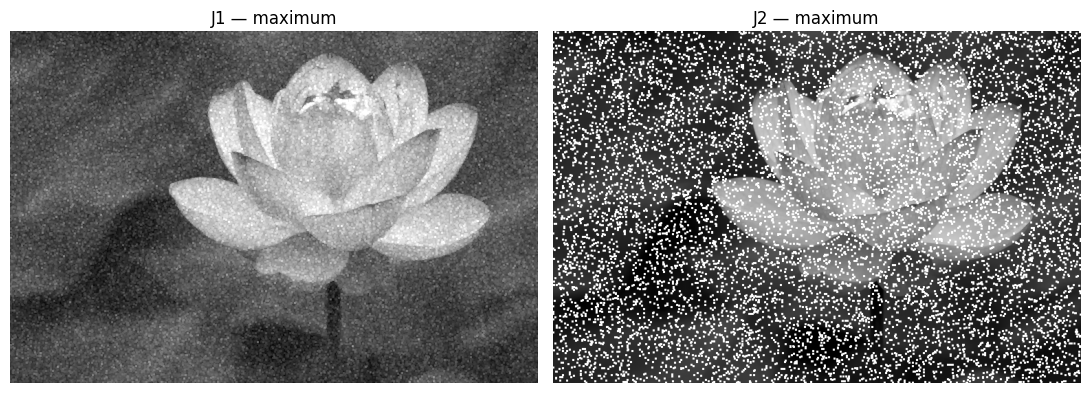

In [10]:
for name, noisy in (("J1", J1), ("J2", J2)):
    filtered[name]["Maximum"] = rank_filter(noisy, "maximum")
show_pair(filtered["J1"]["Maximum"], filtered["J2"]["Maximum"], "J1 — maximum", "J2 — maximum")

## (d) Compare denoising performance (4 pts)

- Report the MSE and PSNR of all ten filtered images in one table.
- Recommend one filter for Gaussian noise and one for salt-and-pepper noise.
- Justify the recommendations in two or three sentences.

In [11]:
rows = []
for noise_name in ("J1", "J2"):
    for filter_name in ("Arithmetic mean", "Gaussian", "Median", "Minimum", "Maximum"):
        estimate = filtered[noise_name][filter_name]
        rows.append({"Noise": noise_name, "Filter": filter_name,
                     "MSE": mse(clean, estimate), "PSNR (dB)": psnr(clean, estimate)})
results = pd.DataFrame(rows)
assert len(results) == 10 and results[["MSE", "PSNR (dB)"]].notna().all().all()
display(results.style.format({"MSE": "{:.3f}", "PSNR (dB)": "{:.3f}"}))
for name in ("J1", "J2"):
    best = results[results["Noise"].eq(name)].sort_values("MSE").iloc[0]
    print(f"{name}: lowest-MSE filter = {best['Filter']} "
          f"(MSE={best['MSE']:.3f}, PSNR={best['PSNR (dB)']:.3f} dB)")

,Noise,Filter,MSE,PSNR (dB)
0,J1,Arithmetic mean,75.798,29.334
1,J1,Gaussian,82.175,28.983
2,J1,Median,112.533,27.618
3,J1,Minimum,1256.672,17.139
4,J1,Maximum,1726.572,15.759
5,J2,Arithmetic mean,146.282,26.479
6,J2,Gaussian,160.306,26.081
7,J2,Median,3.800,42.333
8,J2,Minimum,1509.219,16.343
9,J2,Maximum,7757.376,9.234


J1: lowest-MSE filter = Arithmetic mean (MSE=75.798, PSNR=29.334 dB)
J2: lowest-MSE filter = Median (MSE=3.800, PSNR=42.333 dB)


### Recommendation

For Gaussian white noise, the **arithmetic mean** has the lowest MSE and highest PSNR. Justification: averaging independent zero-mean perturbations reduces their variance.

For salt-and-pepper noise, the **median** has the lowest MSE and highest PSNR. Justification: it selects a reasonable representative of the local neighborhood but not biased to the magnitude of the extrameme values (0 and 255).